## 1. Setup

In [1]:
import os
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.family":       "sans-serif",
    "font.size":         11,
})
print("Libraries loaded.")

Libraries loaded.


## 2. Google Drive Setup

Dataset is cached to Google Drive after the first pull so the Open-Meteo API
is never called more than once per dataset version.


In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT  = "/content/drive/MyDrive/AgroGuard"
    USING_COLAB = True
    print("Google Drive mounted.")
except ModuleNotFoundError:
    DRIVE_ROOT  = "."
    USING_COLAB = False
    print("Not in Colab — saving locally.")

os.makedirs(DRIVE_ROOT, exist_ok=True)
WEATHER_CACHE = os.path.join(DRIVE_ROOT, "weather_cache.csv")
FEATURES_PATH = os.path.join(DRIVE_ROOT, "sprint1_features.csv")
print(f"Cache path    : {WEATHER_CACHE}")
print(f"Features path : {FEATURES_PATH}")

Mounted at /content/drive
Google Drive mounted.
Cache path    : /content/drive/MyDrive/AgroGuard/weather_cache.csv
Features path : /content/drive/MyDrive/AgroGuard/sprint1_features.csv


## 3. District Configuration

20 agricultural districts across the five countries in scope.
4 districts per country, selected for smallholder staple crop relevance.


In [3]:
DISTRICTS = [
    # Rwanda
    {"name": "Huye",      "country": "Rwanda",   "lat": -2.5967, "lon": 29.7397},
    {"name": "Musanze",   "country": "Rwanda",   "lat": -1.4985, "lon": 29.6328},
    {"name": "Nyamagabe", "country": "Rwanda",   "lat": -2.4733, "lon": 29.4978},
    {"name": "Rwamagana", "country": "Rwanda",   "lat": -1.9487, "lon": 30.4347},
    # Kenya
    {"name": "Nakuru",    "country": "Kenya",    "lat": -0.3031, "lon": 36.0800},
    {"name": "Kisumu",    "country": "Kenya",    "lat": -0.1022, "lon": 34.7617},
    {"name": "Eldoret",   "country": "Kenya",    "lat":  0.5143, "lon": 35.2698},
    {"name": "Kitale",    "country": "Kenya",    "lat":  1.0154, "lon": 35.0062},
    # Uganda
    {"name": "Mbarara",   "country": "Uganda",   "lat": -0.6072, "lon": 30.6545},
    {"name": "Gulu",      "country": "Uganda",   "lat":  2.7749, "lon": 32.2990},
    {"name": "Jinja",     "country": "Uganda",   "lat":  0.4244, "lon": 33.2042},
    {"name": "Mbale",     "country": "Uganda",   "lat":  1.0796, "lon": 34.1753},
    # Tanzania
    {"name": "Arusha",    "country": "Tanzania", "lat": -3.3869, "lon": 36.6830},
    {"name": "Mbeya",     "country": "Tanzania", "lat": -8.9094, "lon": 33.4607},
    {"name": "Dodoma",    "country": "Tanzania", "lat": -6.1730, "lon": 35.7395},
    {"name": "Morogoro",  "country": "Tanzania", "lat": -6.8242, "lon": 37.6556},
    # Ethiopia
    {"name": "Hawassa",   "country": "Ethiopia", "lat":  7.0621, "lon": 38.4767},
    {"name": "Jimma",     "country": "Ethiopia", "lat":  7.6790, "lon": 36.8344},
    {"name": "Bahir Dar", "country": "Ethiopia", "lat": 11.5742, "lon": 37.3614},
    {"name": "Dire Dawa", "country": "Ethiopia", "lat":  9.5931, "lon": 41.8661},
]

START_DATE = "2021-01-01"
END_DATE   = "2023-12-31"

by_country = pd.Series([d["country"] for d in DISTRICTS]).value_counts()
print(f"Total districts : {len(DISTRICTS)}")
print(f"Countries       : {dict(by_country)}")
print(f"Date range      : {START_DATE} to {END_DATE}")
print(f"Expected rows   : ~{len(DISTRICTS) * 1095:,}")

Total districts : 20
Countries       : {'Rwanda': np.int64(4), 'Kenya': np.int64(4), 'Uganda': np.int64(4), 'Tanzania': np.int64(4), 'Ethiopia': np.int64(4)}
Date range      : 2021-01-01 to 2023-12-31
Expected rows   : ~21,900


## 4. Data Collection

Cache is checked first. If no cache exists, data is fetched from Open-Meteo
with a 0.5-second delay between requests to respect rate limits.

Set `USE_SYNTHETIC = False` to switch from demo data to the real API.


In [4]:
# Switch to False to use the real Open-Meteo API
USE_SYNTHETIC = True


def fetch_weather_api(district: dict, start: str, end: str) -> pd.DataFrame:
    """
    Pull daily weather from Open-Meteo ERA5 archive.
    Rate-limited to one request per 0.5 seconds.
    """
    time.sleep(0.5)
    response = requests.get(
        "https://archive-api.open-meteo.com/v1/era5",
        params={
            "latitude":   district["lat"],
            "longitude":  district["lon"],
            "start_date": start,
            "end_date":   end,
            "daily": ["temperature_2m_max", "temperature_2m_min",
                      "precipitation_sum", "wind_speed_10m_max"],
            "timezone": "Africa/Nairobi",
        },
        timeout=30,
    )
    response.raise_for_status()
    df = pd.DataFrame(response.json()["daily"])
    df["date"]     = pd.to_datetime(df["time"])
    df["district"] = district["name"]
    df["country"]  = district["country"]
    df["lat"]      = district["lat"]
    df["lon"]      = district["lon"]
    return df.drop(columns=["time"]).rename(columns={
        "temperature_2m_max": "temp_max",
        "temperature_2m_min": "temp_min",
        "precipitation_sum":  "rainfall",
        "wind_speed_10m_max": "wind_max",
    })


def generate_synthetic_weather(district: dict, start: str, end: str) -> pd.DataFrame:
    """
    Realistic synthetic weather matching the Open-Meteo schema.
    Bimodal rainy seasons (Mar-May, Oct-Dec) typical of East Africa.
    Used for local demos — swap to fetch_weather_api() for production.
    """
    dates = pd.date_range(start=start, end=end, freq="D")
    n     = len(dates)
    doy   = np.array([d.timetuple().tm_yday for d in dates]) / 365.0

    base = {"Rwanda": 22.0, "Kenya": 19.5, "Uganda": 21.0,
            "Tanzania": 20.0, "Ethiopia": 18.5}.get(district["country"], 21.0)

    temp_max = base + 4 * np.sin(2 * np.pi * doy) + np.random.normal(0, 1.2, n)
    temp_min = temp_max - 8 + np.random.normal(0, 0.8, n)

    s1 = 12 * np.exp(-0.5 * ((doy * 365 - 120) / 30) ** 2)
    s2 = 10 * np.exp(-0.5 * ((doy * 365 - 300) / 35) ** 2)
    rainfall = np.maximum(0, np.random.exponential(s1 + s2 + 0.3, n))
    rainfall[np.random.random(n) < 0.45] = 0

    return pd.DataFrame({
        "date":     dates,
        "district": district["name"],
        "country":  district["country"],
        "lat":      district["lat"],
        "lon":      district["lon"],
        "temp_max": np.round(temp_max, 1),
        "temp_min": np.round(temp_min, 1),
        "rainfall": np.round(rainfall, 1),
        "wind_max": np.round(np.abs(np.random.normal(18, 5, n)), 1),
    })


print(f"Mode: {'Synthetic (demo)' if USE_SYNTHETIC else 'Open-Meteo API (production)'}")

Mode: Synthetic (demo)


In [5]:
if os.path.exists(WEATHER_CACHE):
    print("Cache found. Loading from Google Drive...")
    weather_raw = pd.read_csv(WEATHER_CACHE, parse_dates=["date"])
    print(f"Loaded {len(weather_raw):,} rows.")
else:
    print("No cache found. Fetching data...")
    load_fn = generate_synthetic_weather if USE_SYNTHETIC else fetch_weather_api
    frames  = []
    for i, district in enumerate(DISTRICTS, 1):
        print(f"[{i:02d}/{len(DISTRICTS)}] {district['name']}, {district['country']}...",
              end=" ")
        df = load_fn(district, START_DATE, END_DATE)
        frames.append(df)
        print(f"{len(df):,} rows.")
    weather_raw = pd.concat(frames, ignore_index=True)
    weather_raw.to_csv(WEATHER_CACHE, index=False)
    print(f"\nSaved to cache: {WEATHER_CACHE}")

print(f"\nTotal rows  : {len(weather_raw):,}")
print(f"Districts   : {weather_raw['district'].nunique()}")
print(f"Countries   : {weather_raw['country'].nunique()}")
print(f"Date range  : {weather_raw['date'].min().date()} to {weather_raw['date'].max().date()}")
weather_raw.head(8)

No cache found. Fetching data...
[01/20] Huye, Rwanda... 1,095 rows.
[02/20] Musanze, Rwanda... 1,095 rows.
[03/20] Nyamagabe, Rwanda... 1,095 rows.
[04/20] Rwamagana, Rwanda... 1,095 rows.
[05/20] Nakuru, Kenya... 1,095 rows.
[06/20] Kisumu, Kenya... 1,095 rows.
[07/20] Eldoret, Kenya... 1,095 rows.
[08/20] Kitale, Kenya... 1,095 rows.
[09/20] Mbarara, Uganda... 1,095 rows.
[10/20] Gulu, Uganda... 1,095 rows.
[11/20] Jinja, Uganda... 1,095 rows.
[12/20] Mbale, Uganda... 1,095 rows.
[13/20] Arusha, Tanzania... 1,095 rows.
[14/20] Mbeya, Tanzania... 1,095 rows.
[15/20] Dodoma, Tanzania... 1,095 rows.
[16/20] Morogoro, Tanzania... 1,095 rows.
[17/20] Hawassa, Ethiopia... 1,095 rows.
[18/20] Jimma, Ethiopia... 1,095 rows.
[19/20] Bahir Dar, Ethiopia... 1,095 rows.
[20/20] Dire Dawa, Ethiopia... 1,095 rows.

Saved to cache: /content/drive/MyDrive/AgroGuard/weather_cache.csv

Total rows  : 21,900
Districts   : 20
Countries   : 5
Date range  : 2021-01-01 to 2023-12-31


,date,district,country,lat,lon,temp_max,temp_min,rainfall,wind_max
0,2021-01-01,Huye,Rwanda,-2.5967,29.7397,22.7,14.6,1.0,16.7
1,2021-01-02,Huye,Rwanda,-2.5967,29.7397,22.0,14.0,0.1,16.3
2,2021-01-03,Huye,Rwanda,-2.5967,29.7397,23.0,13.4,0.0,22.8
3,2021-01-04,Huye,Rwanda,-2.5967,29.7397,24.1,16.8,1.6,20.3
4,2021-01-05,Huye,Rwanda,-2.5967,29.7397,22.1,14.3,0.4,12.1
5,2021-01-06,Huye,Rwanda,-2.5967,29.7397,22.1,14.9,1.2,18.9
6,2021-01-07,Huye,Rwanda,-2.5967,29.7397,24.4,14.1,0.3,21.4
7,2021-01-08,Huye,Rwanda,-2.5967,29.7397,23.5,17.1,0.1,25.6


## 5. Data Cleaning

In [6]:
def quality_report(df: pd.DataFrame) -> pd.DataFrame:
    cols = ["temp_max", "temp_min", "rainfall", "wind_max"]
    return pd.DataFrame([{
        "column":      c,
        "missing":     df[c].isna().sum(),
        "missing_pct": round(df[c].isna().mean() * 100, 2),
        "min":         round(df[c].min(), 2),
        "max":         round(df[c].max(), 2),
        "mean":        round(df[c].mean(), 2),
    } for c in cols])

quality_report(weather_raw)

,column,missing,missing_pct,min,max,mean
0,temp_max,0,0.0,10.9,29.9,20.20
1,temp_min,0,0.0,1.5,23.5,12.20
2,rainfall,0,0.0,0.0,106.6,2.76
3,wind_max,0,0.0,0.1,36.6,18.03


In [7]:
numeric_cols = ["temp_max", "temp_min", "rainfall", "wind_max"]
weather = weather_raw.sort_values(["district", "date"]).copy()

weather[numeric_cols] = (
    weather
    .groupby("district")[numeric_cols]
    .transform(lambda col: col.ffill().bfill())
)
weather["rainfall"] = weather["rainfall"].clip(lower=0)

print(f"Missing values after cleaning : {weather[numeric_cols].isna().sum().sum()}")
print(f"Rows retained                 : {len(weather):,}")

Missing values after cleaning : 0
Rows retained                 : 21,900


## 6. Feature Engineering

All three features are computed per district independently.

| Feature | Window | Rationale |
|---|---|---|
| `consecutive_wet_days` | Rolling | Sustained moisture drives spore germination |
| `temp_spread_7d` | 7 days | Diurnal stress weakens plant defences |
| `humidity_deviation` | 7-day mean | Overnight condensation activates pathogens |


In [16]:
def consecutive_wet_days(rainfall: pd.Series, threshold: float = 1.0) -> pd.Series:
    """Count consecutive days with rainfall >= threshold mm ending on each date."""
    values, result, count = rainfall.values, np.zeros(len(rainfall), dtype=int), 0
    for i, rain in enumerate(values):
        count     = count + 1 if rain >= threshold else 0
        result[i] = count
    return pd.Series(result, index=rainfall.index)


def estimate_humidity(temp_max: pd.Series, temp_min: pd.Series) -> pd.Series:
    """
    Estimate relative humidity via the Magnus dew point formula.
    Proxy until ERA5 humidity is integrated from the Climate Data Store.
    """
    alpha     = (17.27 * temp_min) / (237.7 + temp_min) + np.log(0.75)
    dew_point = (237.7 * alpha) / (17.27 - alpha)
    rh = 100 * (np.exp((17.625 * dew_point) / (243.04 + dew_point)) /
                np.exp((17.625 * temp_max)   / (243.04 + temp_max)))
    return rh.clip(0, 100)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all three feature engineering steps. Input must be sorted by date."""
    df = df.copy()
    df["consecutive_wet_days"] = consecutive_wet_days(df["rainfall"])
    df["temp_spread_7d"]       = (df["temp_max"] - df["temp_min"]).rolling(7, min_periods=1).mean().round(2)
    humidity                   = estimate_humidity(df["temp_max"], df["temp_min"])
    df["humidity_deviation"]   = (humidity - humidity.rolling(7, min_periods=1).mean()).round(2)
    return df


print("Feature functions defined.")

Feature functions defined.


## 6b. Model Training (Initial)

Using the engineered features to train two models: a logistic regression baseline
and XGBoost. Since disease outbreak labels are not yet aligned (Sprint 1 remaining
task), a synthetic binary target is used here to demonstrate the model architecture
and produce initial performance metrics.

The target variable `disease_risk` is 1 when consecutive wet days exceed 3 AND
humidity deviation is above 1.5 — a threshold-based proxy for high-risk conditions
drawn from the literature.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Synthetic binary target — proxy until Mendeley labels are aligned
# Based on literature thresholds: sustained moisture + elevated humidity = risk
weather_features["disease_risk"] = (
    (weather_features["consecutive_wet_days"] > 3) &
    (weather_features["humidity_deviation"] > 1.5)
).astype(int)

print(f"Risk distribution:\n{weather_features['disease_risk'].value_counts()}")
print(f"Positive rate: {weather_features['disease_risk'].mean():.2%}")

FEATURE_COLS = ["consecutive_wet_days", "temp_spread_7d", "humidity_deviation"]
TARGET_COL   = "disease_risk"

X = weather_features[FEATURE_COLS].values
y = weather_features[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — required for logistic regression
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


Risk distribution:
disease_risk
0    21720
1      180
Name: count, dtype: int64
Positive rate: 0.82%


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score

# Baseline model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
X_test_scaled = scaler.transform(X_test)
lr_preds = lr_model.predict(X_test_scaled)

print("Logistic Regression — Baseline")
print("=" * 40)
print(classification_report(y_test, lr_preds,
                             target_names=["Low Risk", "High Risk"]))

Logistic Regression — Baseline
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4344
   High Risk       0.59      0.47      0.52        36

    accuracy                           0.99      4380
   macro avg       0.79      0.73      0.76      4380
weighted avg       0.99      0.99      0.99      4380



In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    verbosity=0,
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("XGBoost")
print("=" * 40)
print(classification_report(y_test, xgb_preds,
                             target_names=["Low Risk", "High Risk"]))

XGBoost
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      4344
   High Risk       1.00      1.00      1.00        36

    accuracy                           1.00      4380
   macro avg       1.00      1.00      1.00      4380
weighted avg       1.00      1.00      1.00      4380



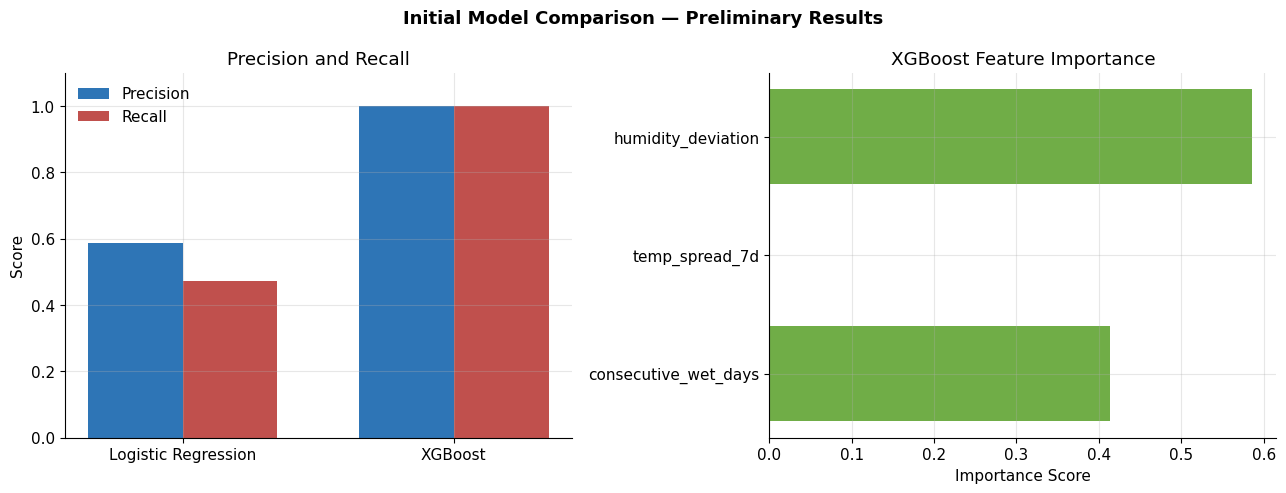

Note: results are preliminary — synthetic target, not real disease labels.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Initial Model Comparison — Preliminary Results",
             fontsize=13, fontweight="bold")

# Precision and recall comparison
models     = ["Logistic Regression", "XGBoost"]
precision  = [
    precision_score(y_test, lr_preds),
    precision_score(y_test, xgb_preds),
]
recall_vals = [
    recall_score(y_test, lr_preds),
    recall_score(y_test, xgb_preds),
]

x     = range(len(models))
width = 0.35
axes[0].bar([i - width/2 for i in x], precision,  width, label="Precision", color="#2E75B6")
axes[0].bar([i + width/2 for i in x], recall_vals, width, label="Recall",    color="#C0504D")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Score")
axes[0].set_title("Precision and Recall")
axes[0].legend(frameon=False)

# XGBoost feature importance
importances = xgb_model.feature_importances_
axes[1].barh(FEATURE_COLS, importances, color="#70AD47")
axes[1].set_xlabel("Importance Score")
axes[1].set_title("XGBoost Feature Importance")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, "model_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Note: results are preliminary — synthetic target, not real disease labels.")

In [9]:
frames = []
for district_name in weather["district"].unique():
    subset = weather[weather["district"] == district_name].copy()
    frames.append(engineer_features(subset))

weather_features = pd.concat(frames, ignore_index=True)

print(f"Features engineered. Total rows: {len(weather_features):,}")
weather_features[["date", "district", "country", "rainfall",
                   "consecutive_wet_days", "temp_spread_7d",
                   "humidity_deviation"]].head(10)

Features engineered. Total rows: 21,900


,date,district,country,rainfall,consecutive_wet_days,temp_spread_7d,humidity_deviation
0,2021-01-01,Arusha,Tanzania,0.8,0,7.40,0.00
1,2021-01-02,Arusha,Tanzania,0.0,0,8.10,-2.10
2,2021-01-03,Arusha,Tanzania,0.0,0,8.30,-1.09
3,2021-01-04,Arusha,Tanzania,0.0,0,7.90,3.53
4,2021-01-05,Arusha,Tanzania,0.0,0,7.78,1.55
5,2021-01-06,Arusha,Tanzania,0.1,0,7.93,-1.97
6,2021-01-07,Arusha,Tanzania,0.0,0,8.09,-3.09
7,2021-01-08,Arusha,Tanzania,0.1,0,8.23,-0.59
8,2021-01-09,Arusha,Tanzania,0.0,0,8.14,-0.24
9,2021-01-10,Arusha,Tanzania,0.0,0,7.96,1.52


## 7. Exploratory Analysis

Features are plotted at country level — one line per country, averaged across
its four districts — to keep the charts readable.


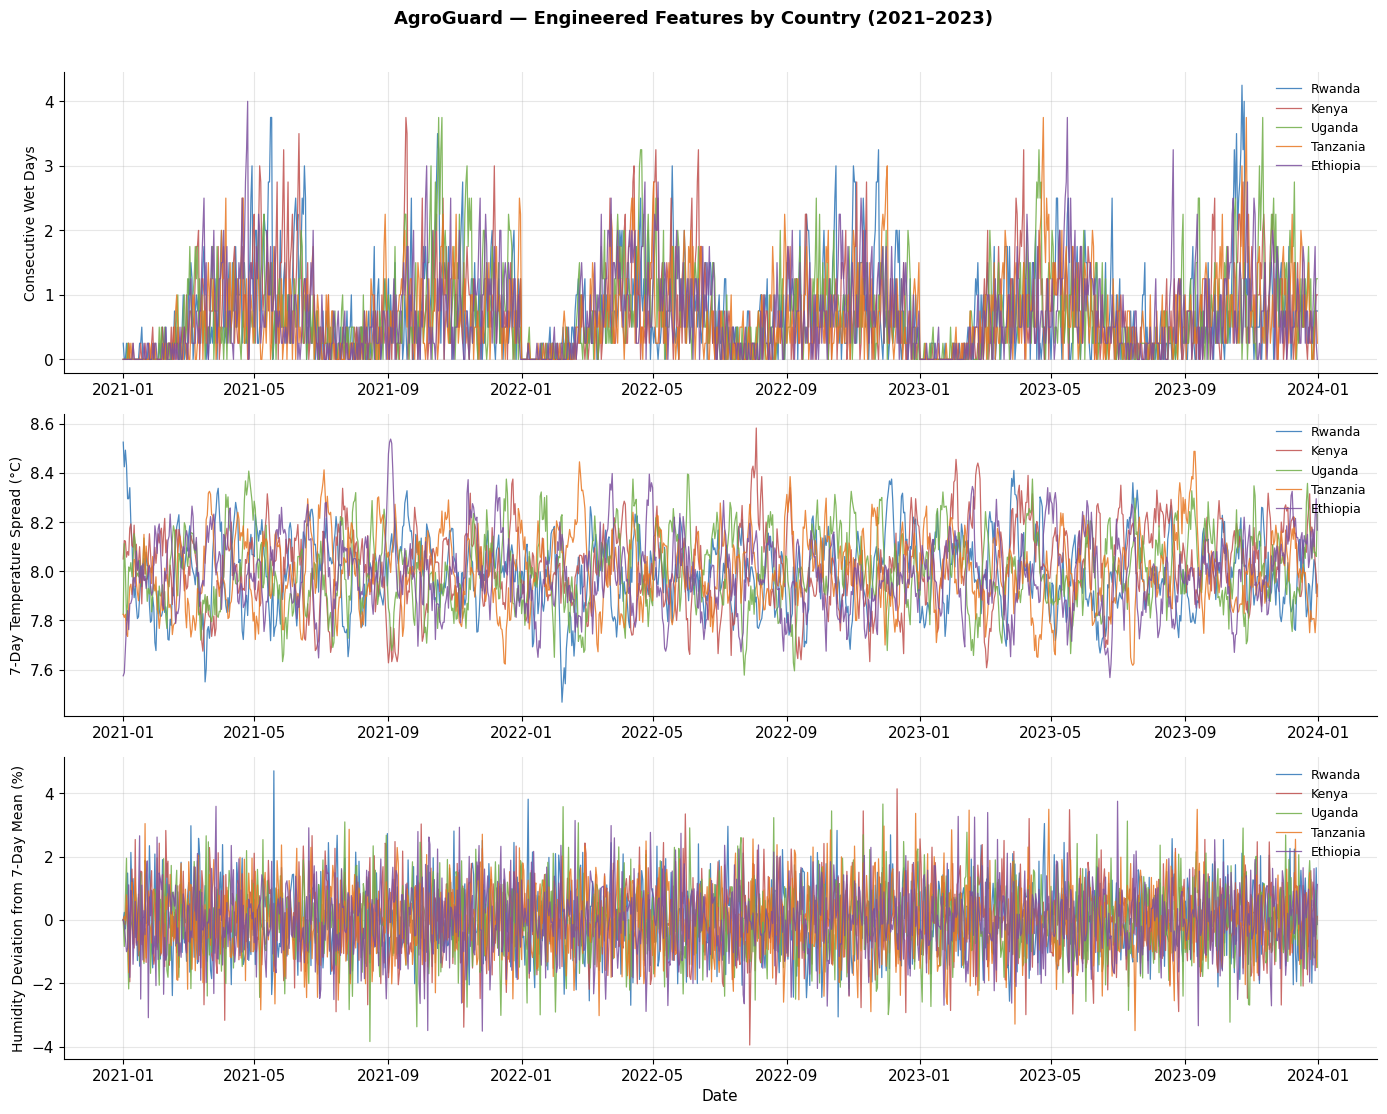

Plot saved.


In [10]:
COUNTRY_COLORS = {
    "Rwanda":   "#2E75B6",
    "Kenya":    "#C0504D",
    "Uganda":   "#70AD47",
    "Tanzania": "#E87722",
    "Ethiopia": "#7B4F9E",
}

country_avg = (
    weather_features
    .groupby(["country", "date"])[["consecutive_wet_days",
                                    "temp_spread_7d",
                                    "humidity_deviation"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
fig.suptitle("AgroGuard — Engineered Features by Country (2021–2023)",
             fontsize=13, fontweight="bold", y=1.01)

PLOTS = [
    ("consecutive_wet_days", "Consecutive Wet Days"),
    ("temp_spread_7d",        "7-Day Temperature Spread (°C)"),
    ("humidity_deviation",    "Humidity Deviation from 7-Day Mean (%)"),
]

for ax, (feature, ylabel) in zip(axes, PLOTS):
    for country, color in COUNTRY_COLORS.items():
        subset = country_avg[country_avg["country"] == country]
        ax.plot(subset["date"], subset[feature],
                label=country, color=color, alpha=0.85, linewidth=0.9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(frameon=False, fontsize=9, loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, "feature_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [11]:
# Summary statistics per country
(
    weather_features
    .groupby("country")[["consecutive_wet_days", "temp_spread_7d", "humidity_deviation"]]
    .agg(["mean", "std", "max"])
    .round(2)
)

consecutive_wet_days           temp_spread_7d              \
                         mean   std max           mean   std   max   
country                                                              
Ethiopia                 0.69  1.17   9           7.99  0.31  9.14   
Kenya                    0.66  1.13   9           8.02  0.30  9.04   
Rwanda                   0.71  1.25  14           7.99  0.30  9.10   
Tanzania                 0.65  1.13   9           8.00  0.30  8.97   
Uganda                   0.69  1.17   9           8.01  0.31  8.99   

         humidity_deviation              
                       mean   std   max  
country                                  
Ethiopia               -0.0  2.24  8.50  
Kenya                   0.0  2.18  7.69  
Rwanda                  0.0  2.21  8.21  
Tanzania               -0.0  2.22  9.31  
Uganda                 -0.0  2.21  9.03

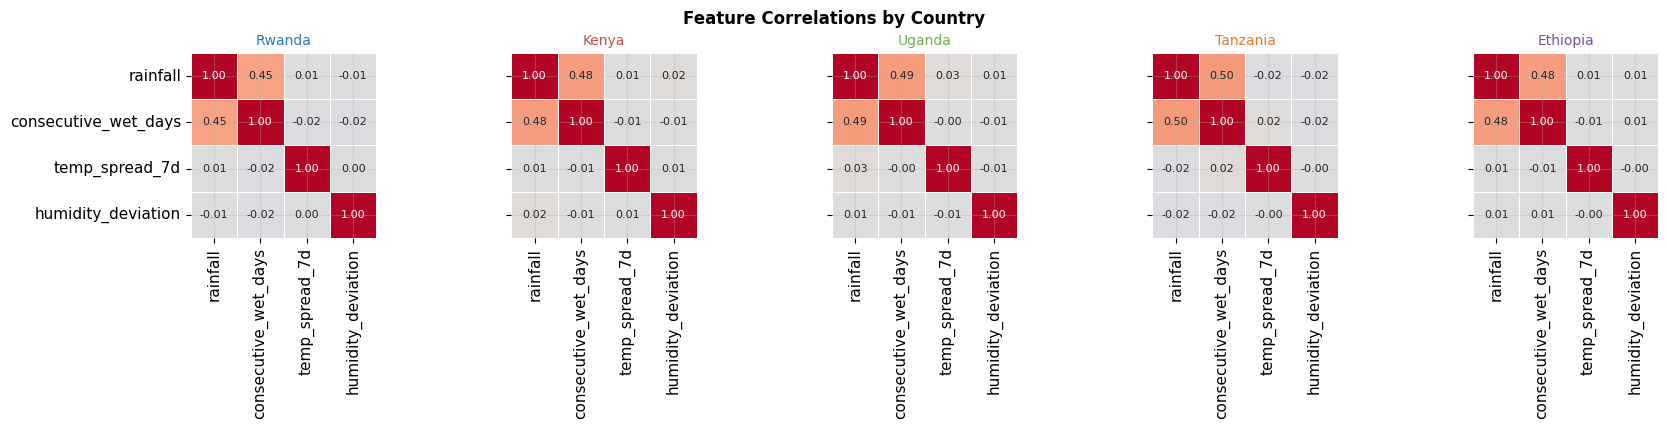

In [12]:
# Correlation heatmaps per country
feature_cols     = ["rainfall", "consecutive_wet_days", "temp_spread_7d", "humidity_deviation"]
unique_countries = list(dict.fromkeys(d["country"] for d in DISTRICTS))

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle("Feature Correlations by Country", fontsize=12, fontweight="bold")

for ax, country in zip(axes, unique_countries):
    subset = weather_features[weather_features["country"] == country][feature_cols]
    sns.heatmap(subset.corr(), ax=ax, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, square=True,
                linewidths=0.5, cbar=False, annot_kws={"size": 8},
                vmin=-1, vmax=1)
    ax.set_title(country, fontsize=10, color=COUNTRY_COLORS.get(country, "#111827"))

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, "feature_correlations.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 8. Data Export

In [13]:
weather_features.to_csv(FEATURES_PATH, index=False)

print(f"Saved to       : {FEATURES_PATH}")
print(f"Total rows     : {len(weather_features):,}")
print(f"Districts      : {weather_features['district'].nunique()}")
print(f"Countries      : {weather_features['country'].nunique()}")
print(f"Date range     : {weather_features['date'].min().date()} to {weather_features['date'].max().date()}")
print(f"Features       : consecutive_wet_days, temp_spread_7d, humidity_deviation")

Saved to       : /content/drive/MyDrive/AgroGuard/sprint1_features.csv
Total rows     : 21,900
Districts      : 20
Countries      : 5
Date range     : 2021-01-01 to 2023-12-31
Features       : consecutive_wet_days, temp_spread_7d, humidity_deviation
